# EDA 05 — How prevalent is imputation, and is it independent of sampling noise?

**Question (README, Phase 1 Step 5, final item):** How prevalent is imputation (allocation) in our Phase 1 variables — and do allocation rates correlate with high-CV geographies? **If they are independent, a multi-component composite score is empirically justified** (Q2): sampling reliability and data-completeness would be two genuinely different axes of fitness-for-use.

**Plain-English setup.** When a household skips a question, the Census Bureau fills the blank with a statistically plausible value — **imputation**, which the ACS documentation calls **allocation**. The **item allocation rate** is the share of a variable's published values that were filled in rather than reported (see [`docs/glossary.md`](../docs/glossary.md)). Crucially, imputation is a *different kind* of uncertainty from sampling noise: the MOE measures the wobble from sampling *the people who answered*; the allocation rate measures how much of the underlying data was never really answered at all. An estimate can have a tight MOE built on heavily-imputed data.

**Measurement facts that shape this notebook** (verified live against the API by `ingestion/pull_acs_alloc_nj.py`):
- Allocation tables publish **no margins of error** — allocation rate enters the analysis as a covariate, not a CV-bearing estimate.
- The Bureau's ready-made "overall person characteristic allocation rate" (B98031) is published at **county level only** — every tract and block-group value is null. Item-level tables (sex, age, race, household income, family poverty) are fully populated at county, tract, AND block group.
- There is **no person-level poverty allocation table**. Poverty status is derived from income, so the closest published table is family-level (B99172). We use it as a **labeled proxy** — its universe (families) does not match our poverty variable's universe (people) — and the label travels with the number everywhere it appears.

**Data.** ACS 5-year vintage 2024, New Jersey. Allocation tables: `python ingestion/pull_acs_alloc_nj.py`; estimates + MOEs: `python ingestion/pull_acs_nj.py`. Shared formulas: [`analysis/acs.py`](../analysis/acs.py).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Notebook lives in /notebooks; the analysis package lives at the repo root.
REPO_ROOT = Path.cwd() if (Path.cwd() / "analysis").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
from analysis import acs

LEVELS = ["county", "tract", "block_group"]
KEYS = {"county": ["STATE", "COUNTY"],
        "tract": ["STATE", "COUNTY", "TRACT"],
        "block_group": ["STATE", "COUNTY", "TRACT", "BLOCK_GROUP"]}
EXPECTED_ROWS = {"county": 21, "tract": 2_181, "block_group": 6_599}


def load_alloc(level: str) -> pd.DataFrame:
    """One level of the allocation pull, numeric-coerced (raw keeps API types)."""
    path = REPO_ROOT / "data" / "raw" / f"acs5_2024_nj_alloc_{level}.parquet"
    if not path.exists():
        raise FileNotFoundError(f"{path} -- regenerate with: python ingestion/pull_acs_alloc_nj.py")
    df = pd.read_parquet(path)
    value_cols = [c for c in df.columns if c.startswith("B9")]
    df[value_cols] = df[value_cols].apply(pd.to_numeric, errors="coerce")
    return df


# Merge allocation onto the estimate pull, level by level -- a partial join
# would silently drop geographies from every correlation below.
merged = {}
for level in LEVELS:
    est, alloc = acs.load_level(level), load_alloc(level)
    m = est.merge(alloc, on=KEYS[level], how="outer", indicator=True,
                  suffixes=("", "_allocfile"))
    assert (m["_merge"] == "both").all(), f"{level}: estimate/allocation rows must match 1:1"
    assert len(m) == EXPECTED_ROWS[level], f"{level}: expected {EXPECTED_ROWS[level]} rows"
    merged[level] = m.drop(columns="_merge")
    print(f"{level:<12} {len(m):>6,} geographies, estimate + allocation joined 1:1")

county           21 geographies, estimate + allocation joined 1:1
tract         2,181 geographies, estimate + allocation joined 1:1
block_group   6,599 geographies, estimate + allocation joined 1:1


## 1. Data quality before analysis

Checks, in order: the demographic allocation tables must share one universe (total population — their totals should be identical); allocated + not-allocated must sum to the total exactly; the income and poverty bin tables must sum to their totals; and the B98031 county-only limitation is pinned down as a fact rather than left as a surprise.

In [2]:
for level in LEVELS:
    m = merged[level]
    # One universe behind sex/age/race allocation: identical totals.
    assert m["B99011_001E"].equals(m["B99012_001E"]) and m["B99011_001E"].equals(m["B99021_001E"]), \
        f"{level}: sex/age/race allocation totals should be identical (same universe)"
    # Internal additivity -- exact, these are tabulated counts.
    for g in ("B99011", "B99012", "B99021"):
        assert (m[f"{g}_002E"] + m[f"{g}_003E"] == m[f"{g}_001E"]).all(), f"{level}: {g} additivity"
    assert (m[[f"B99192_{i:03d}E" for i in range(2, 9)]].sum(axis=1) == m["B99192_001E"]).all(), \
        f"{level}: B99192 bins must sum to total households"
    assert (m[[f"B99172_{i:03d}E" for i in range(2, 16)]].sum(axis=1) == m["B99172_001E"]).all(), \
        f"{level}: B99172 bins must sum to total families"
    print(f"{level:<12} additivity + shared-universe checks pass")

# The B98031/B98032 landmine, pinned: county-only publication.
for level in ("tract", "block_group"):
    nulls = merged[level]["B98031_001E"].isna().mean()
    assert nulls == 1.0, f"B98031 unexpectedly populated at {level}"
print("\nB98031/B98032 (overall allocation rates): 100% null below county level -- "
      "county-only, as documented in docs/data-dictionary.md")
print(f"Zero annotation codes in any allocation column at any level: "
      f"{all(not (merged[lv].filter(like='B99').le(-111111111)).any().any() for lv in LEVELS)}")

county       additivity + shared-universe checks pass
tract        additivity + shared-universe checks pass
block_group  additivity + shared-universe checks pass

B98031/B98032 (overall allocation rates): 100% null below county level -- county-only, as documented in docs/data-dictionary.md
Zero annotation codes in any allocation column at any level: True


## 2. Deriving allocation rates

Our methodology (rates are not published directly except B98031; *source for table structure: ACS detailed tables B99011/B99012/B99021/B99192/B99172, labels verified at run time by the pull script*):

| Rate | Formula | Universe |
|---|---|---|
| `sex_alloc`, `age_alloc`, `race_alloc` | `allocated / total` (`_002/_001`) | total population |
| `income_alloc` | `1 − (no income allocated / total)` = share of households with **any** income imputed | households |
| `fam_pov_alloc` *(proxy)* | `1 − (below_no_alloc + above_no_alloc) / total` | **families** — not people |
| `overall_alloc` | `B98031 / 100` | total population (county only) |

Everything is normalized to **fractions 0–1 immediately** (one `÷100` for B98031, applied exactly once) and rates are undefined (NaN) where the denominator is zero — the same rule as our CV convention.

In [3]:
def derive_rates(df: pd.DataFrame) -> pd.DataFrame:
    """Add allocation-rate columns (fractions 0-1; NaN where denominator 0)."""
    out = df.copy()
    def safe_div(num, den):
        return num / den.where(den > 0)
    out["sex_alloc"] = safe_div(df["B99011_002E"], df["B99011_001E"])
    out["age_alloc"] = safe_div(df["B99012_002E"], df["B99012_001E"])
    out["race_alloc"] = safe_div(df["B99021_002E"], df["B99021_001E"])
    out["demo_mean_alloc"] = out[["sex_alloc", "age_alloc", "race_alloc"]].mean(axis=1)
    out["income_alloc"] = 1 - safe_div(df["B99192_002E"], df["B99192_001E"])
    out["fam_pov_alloc"] = 1 - safe_div(df["B99172_002E"] + df["B99172_009E"], df["B99172_001E"])
    out["overall_alloc"] = df["B98031_001E"] / 100  # published as a percent
    return out


RATES = ["overall_alloc", "sex_alloc", "age_alloc", "race_alloc",
         "income_alloc", "fam_pov_alloc"]
for level in LEVELS:
    merged[level] = derive_rates(merged[level])
    for r in RATES:
        s = merged[level][r].dropna()
        if len(s):
            assert s.between(0, 1).all(), f"{level}/{r}: rate outside [0, 1] -- unit bug"
print("All derived rates within [0, 1] at every level.")

All derived rates within [0, 1] at every level.


## 3. How prevalent is imputation?

In [4]:
rows = []
for level in LEVELS:
    for r in RATES:
        s = merged[level][r].dropna()
        if not len(s):
            continue
        rows.append({"level": level, "rate": r, "n": len(s),
                     "median": s.median(), "IQR low": s.quantile(0.25),
                     "IQR high": s.quantile(0.75), "max": s.max()})
prevalence = pd.DataFrame(rows).set_index(["level", "rate"])

t = merged["tract"]
# Guard the headline claims.
assert t["income_alloc"].median() > 0.30, "income imputation should be widespread"
assert t["sex_alloc"].median() < 0.001, "sex should be almost never imputed"
assert merged["county"]["overall_alloc"].between(0.10, 0.20).all(), \
    "overall county allocation rates should sit in the low teens"
prevalence.round(4)

n  median  IQR low  IQR high     max
level       rate                                                  
county      overall_alloc    21  0.1470   0.1340    0.1500  0.1640
            sex_alloc        21  0.0005   0.0004    0.0007  0.0018
            age_alloc        21  0.0113   0.0095    0.0147  0.0290
            race_alloc       21  0.0133   0.0125    0.0159  0.0353
            income_alloc     21  0.3938   0.3812    0.4081  0.4635
            fam_pov_alloc    21  0.4089   0.3925    0.4338  0.4856
tract       sex_alloc      2172  0.0000   0.0000    0.0000  0.0419
            age_alloc      2172  0.0076   0.0018    0.0186  0.2048
            race_alloc     2172  0.0074   0.0002    0.0187  0.9736
            income_alloc   2166  0.3933   0.3317    0.4643  1.0000
            fam_pov_alloc  2163  0.4131   0.3445    0.4979  1.0000
block_group sex_alloc      6528  0.0000   0.0000    0.0000  0.1070
            age_alloc      6528  0.0000   0.0000    0.0143  0.4819
            race_alloc     6528  0.0000   0.0000    0.0132  0.9957
            income_alloc   6510  0.3901   0.2991    0.4979  1.0000
            fam_pov_alloc  6498  0.4095   0.3016    0.5354  1.0000

**What the table says.**

- **Imputation is common — and wildly uneven across variables.** At the median NJ tract, **~39% of households had some income imputed**, and the family-poverty proxy is similar (~41%) — while age and race are imputed for under 1% of people and sex for ~0.05%. That's roughly **three orders of magnitude** between the most- and least-imputed items: imputation prevalence is a *variable-type* story, just as sampling reliability was in EDA 02.
- **Overall, about one in seven person characteristics is imputed** (county overall rates 11.5–16.4%, median 14.7%) — imputation is not a footnote-sized phenomenon.
- The tract maxima (race allocation up to 97%, income to 100%) come from small-denominator geographies — the same small-area fragility every other uncertainty source shows.
- None of this is visible in an MOE: allocation tables ship no margins of error, and MOEs don't widen because data was imputed. Two tracts with identical CVs can differ enormously in how much of their data is real — *if* the two measures are independent. That's the next section's question.

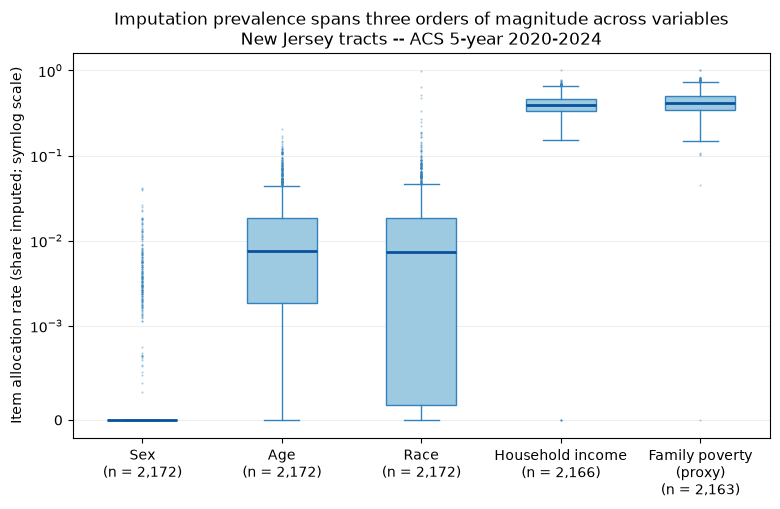

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_rates = ["sex_alloc", "age_alloc", "race_alloc", "income_alloc", "fam_pov_alloc"]
labels = ["Sex", "Age", "Race", "Household income", "Family poverty\n(proxy)"]
data = [merged["tract"][r].dropna().to_numpy() for r in plot_rates]
ax.boxplot(data, tick_labels=[f"{l}\n(n = {len(d):,})" for l, d in zip(labels, data)],
           patch_artist=True,
           boxprops=dict(facecolor="#9ecae1", edgecolor="#3182bd"),
           medianprops=dict(color="#08519c", linewidth=2),
           whiskerprops=dict(color="#3182bd"), capprops=dict(color="#3182bd"),
           flierprops=dict(marker=".", markersize=3, markerfacecolor="#3182bd",
                           markeredgecolor="none", alpha=0.4))
ax.set_yscale("symlog", linthresh=1e-3)  # sex/age/race medians are near zero
ax.set_ylabel("Item allocation rate (share imputed; symlog scale)")
ax.set_title("Imputation prevalence spans three orders of magnitude across variables\n"
             "New Jersey tracts -- ACS 5-year 2020-2024", fontsize=12)
ax.grid(axis="y", which="both", alpha=0.2)
plt.show()

## 4. Is imputation independent of sampling reliability? (the composite-score test)

**Method.** For each variable we pair its **allocation rate** with its **CV** across tracts and compute two Spearman rank correlations (ranks via `rank().corr()`, the notebook 03 idiom — no scipy):

1. **Raw** — the naive association.
2. **Size-controlled** — the honest one. CV depends mechanically on geography size (EDA 02's $-\tfrac{1}{2}$ law), so if allocation rates also vary with size, a raw correlation partly measures *size*, not a real link between imputation and sampling noise. We remove the known size→CV relationship first — residualize $\log_{10}(\mathrm{CV})$ on $\log_{10}(\text{universe count})$ with `np.polyfit` (the EDA 02 machinery) — then correlate the allocation rate against what remains. **The control variable is the universe *count* behind each estimate** (people for population pairings, households for income, the poverty count for poverty), never the estimate's dollar value.

**The claim that matters for Q2 rests on the controlled column.** CV pairings: population and Black 65+ aggregate CVs from the EDA 02 machinery (`aggregate_estimate`/`aggregate_moe`); income CV excludes the 41 top-coded tracts (consistent with EDA 01/02); every pairing uses a single pairwise-complete mask with `n` reported.

In [6]:
t = merged["tract"]
topcoded = acs.flag_topcoded_income(t)
cv_pop = acs.cv(t["B01003_001E"], t["B01003_001M"])
cv_inc = acs.cv(t["B19013_001E"], t["B19013_001M"]).where(~topcoded)
cv_pov = acs.cv(t["B17001_002E"], t["B17001_002M"])
b65_est = acs.aggregate_estimate(t, acs.BLACK_65PLUS_CELLS)
b65_moe = acs.aggregate_moe(t, acs.BLACK_65PLUS_CELLS)
cv_b65 = acs.cv(b65_est, b65_moe)
print(f"Top-coded tracts excluded from the income CV: {int(topcoded.sum())}")


def spearman(a: pd.Series, b: pd.Series) -> tuple[float, int]:
    """Raw Spearman on the pairwise-complete mask (rank().corr(), no scipy)."""
    m = a.notna() & b.notna()
    return float(a[m].rank().corr(b[m].rank())), int(m.sum())


def controlled_spearman(rate: pd.Series, cv: pd.Series, size: pd.Series) -> tuple[float, int]:
    """Spearman of rate vs the CV residual after removing the size law.

    Fits log10(cv) ~ log10(size) on the pairwise mask (np.polyfit, EDA 02
    convention) and correlates the rate with the residual -- what is left
    of CV once its mechanical size dependence is removed.
    """
    m = rate.notna() & cv.notna() & size.notna() & (cv > 0) & (size > 0)
    lx, ly = np.log10(size[m]), np.log10(cv[m])
    slope, intercept = np.polyfit(lx, ly, 1)
    resid = ly - (slope * lx + intercept)
    return float(rate[m].rank().corr(resid.rank())), int(m.sum())


PAIRINGS = [
    ("Age allocation vs population CV", "age_alloc", cv_pop, t["B01003_001E"]),
    ("Income allocation vs income CV", "income_alloc", cv_inc, t["B99192_001E"]),
    ("Sex allocation vs Black 65+ CV", "sex_alloc", cv_b65, b65_est),
    ("Age allocation vs Black 65+ CV", "age_alloc", cv_b65, b65_est),
    ("Race allocation vs Black 65+ CV", "race_alloc", cv_b65, b65_est),
    ("Demographic mean vs Black 65+ CV", "demo_mean_alloc", cv_b65, b65_est),
    ("Family-poverty alloc vs poverty CV (PROXY: families)", "fam_pov_alloc", cv_pov, t["B17001_002E"]),
]

results = []
for name, rate_col, cv_s, size in PAIRINGS:
    raw, _ = spearman(t[rate_col], cv_s)
    ctrl, n = controlled_spearman(t[rate_col], cv_s, size)
    results.append({"pairing": name, "raw rho": raw, "controlled rho": ctrl, "n": n})
results = pd.DataFrame(results).set_index("pairing")

# Guard the notebook's claims.
assert (results["n"] >= 1_500).all(), "every pairing should keep most tracts"
assert results["controlled rho"].abs().max() < 0.25, \
    "independence claim: no controlled correlation should be even moderately strong"
fp_raw = results.loc[results.index.str.contains("PROXY"), "raw rho"].iloc[0]
fp_ctrl = results.loc[results.index.str.contains("PROXY"), "controlled rho"].iloc[0]
assert fp_raw < -0.10 and abs(fp_ctrl) < 0.10, \
    "the poverty pairing's raw correlation should collapse once size is controlled"
results.round(2)

Top-coded tracts excluded from the income CV: 41


,raw rho,controlled rho,n
pairing,,,
Age allocation vs population CV,0.11,0.11,2172
Income allocation vs income CV,0.20,0.19,2109
Sex allocation vs Black 65+ CV,-0.03,-0.00,1596
Age allocation vs Black 65+ CV,-0.08,0.06,1596
Race allocation vs Black 65+ CV,-0.04,-0.00,1596
Demographic mean vs Black 65+ CV,-0.09,0.05,1596
Family-poverty alloc vs poverty CV (PROXY: families),-0.18,0.02,2158


**What the table says — the verdict is independence.**

- Every **size-controlled** correlation sits between **−0.00 and +0.19**. Knowing a tract's allocation rate tells you essentially nothing about its sampling reliability, and vice versa. **Imputation is an independent axis of uncertainty — the multi-component composite score is empirically justified.**
- The poverty row is the methods lesson: raw ρ = **−0.18** looks like "more imputation, better CV" — nonsense — and collapses to **+0.02** once size is controlled. High-poverty tracts tend to have *larger* poverty counts (hence smaller CVs) *and* more imputation; size was driving both. This is exactly why the controlled column is the one the composite score leans on.
- The strongest controlled association anywhere is income at **+0.19** — weak, and plausibly real (households that resist answering income questions may also be harder to sample precisely) — worth a mentor mention, not a score-design change.
- A quiet cross-check: the size slopes the residualization estimates (−0.47 population, −0.51 Black 65+, −0.18 poverty) reproduce EDA 02's published slopes almost exactly — the two notebooks agree on the size law from independent code paths.

## 5. Depth check: county and block group

County is context only — 21 observations make rank correlations coarse, and the county **population** CV doesn't exist at all (county totals are controlled estimates with no published MOE, the EDA 01 finding). Block group repeats the two pairings whose CVs survive to that level. Block-group caveat: small-denominator rates are noisy, which attenuates correlations toward zero — so we also run a denominator ≥ 50 sensitivity line.

In [7]:
c = merged["county"]
print("County (n = 21, context only) -- overall allocation rate (B98031) vs CVs, raw Spearman:")
for name, cv_s in [("population CV", acs.cv(c["B01003_001E"], c["B01003_001M"])),
                   ("income CV", acs.cv(c["B19013_001E"], c["B19013_001M"])),
                   ("poverty CV", acs.cv(c["B17001_002E"], c["B17001_002M"]))]:
    rho, n = spearman(c["overall_alloc"], cv_s)
    note = "  <- controlled estimates: no MOE, CV undefined (EDA 01)" if n == 0 else ""
    print(f"  vs {name:<15} rho = {rho if n else float('nan'):+.2f}  (n = {n}){note}")

bg = merged["block_group"]
top_bg = acs.flag_topcoded_income(bg)
cv_pop_bg = acs.cv(bg["B01003_001E"], bg["B01003_001M"])
cv_inc_bg = acs.cv(bg["B19013_001E"], bg["B19013_001M"]).where(~top_bg)
print(f"\nBlock group (top-coded excluded: {int(top_bg.sum())}):")
bg_ctrl = {}
for name, rate_col, cv_s, size in [
    ("Age allocation vs population CV", "age_alloc", cv_pop_bg, bg["B01003_001E"]),
    ("Income allocation vs income CV", "income_alloc", cv_inc_bg, bg["B99192_001E"]),
]:
    raw, _ = spearman(bg[rate_col], cv_s)
    ctrl, n = controlled_spearman(bg[rate_col], cv_s, size)
    big = size >= 50
    ctrl_s, n_s = controlled_spearman(bg[rate_col].where(big), cv_s, size)
    bg_ctrl[rate_col] = ctrl
    print(f"  {name:<34} raw {raw:+.2f}  controlled {ctrl:+.2f} (n = {n:,})"
          f"  |  denom>=50 sensitivity: {ctrl_s:+.2f} (n = {n_s:,})")

assert max(abs(v) for v in bg_ctrl.values()) < 0.25, "independence should hold at block group too"
print("\nIndependence holds at block group as well.")

County (n = 21, context only) -- overall allocation rate (B98031) vs CVs, raw Spearman:
  vs population CV   rho = +nan  (n = 0)  <- controlled estimates: no MOE, CV undefined (EDA 01)
  vs income CV       rho = -0.23  (n = 21)
  vs poverty CV      rho = -0.49  (n = 21)

Block group (top-coded excluded: 270):
  Age allocation vs population CV    raw -0.13  controlled -0.06 (n = 6,528)  |  denom>=50 sensitivity: -0.06 (n = 6,512)
  Income allocation vs income CV     raw +0.09  controlled +0.08 (n = 5,785)  |  denom>=50 sensitivity: +0.09 (n = 5,782)

Independence holds at block group as well.


## 6. The chart — four pairings, no relationship

One panel per lead-approved pairing, tract level: allocation rate (x) against CV (y, log scale), with the raw and size-controlled Spearman ρ annotated. A flat, structureless cloud in every panel is the *desired* result — visual confirmation that the composite score's components measure different things.

Chart saved to data\processed\eda05_allocation_vs_cv.png (local-only, regenerable)


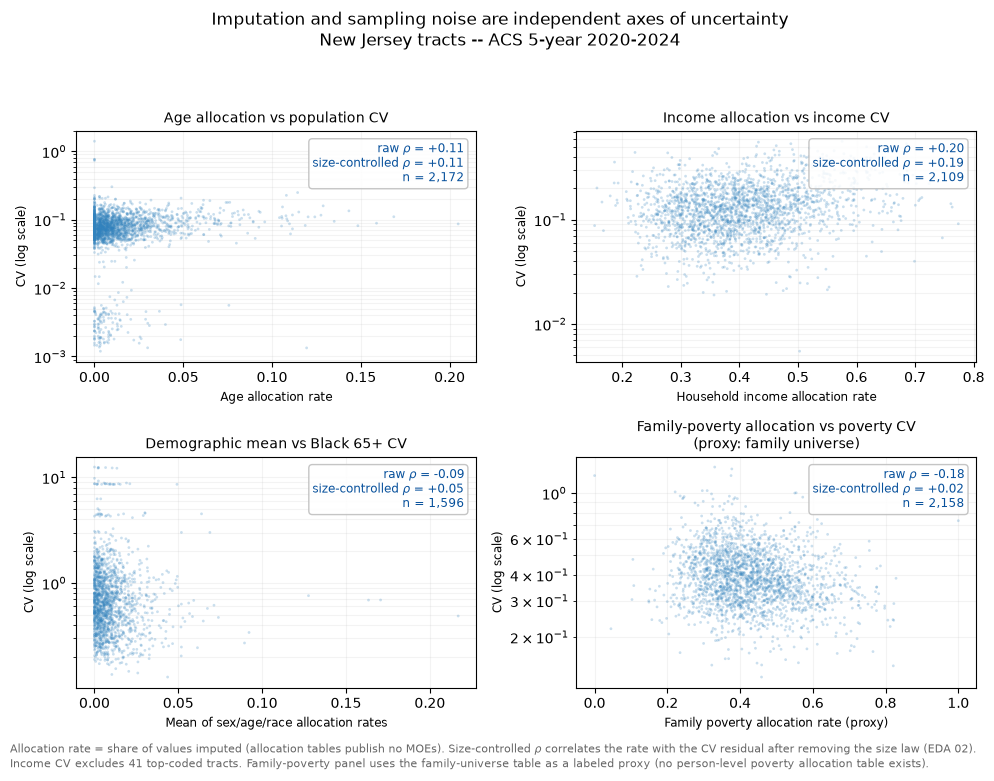

In [8]:
panels = [
    ("Age allocation vs population CV", "age_alloc", cv_pop, t["B01003_001E"], "Age allocation rate"),
    ("Income allocation vs income CV", "income_alloc", cv_inc, t["B99192_001E"], "Household income allocation rate"),
    ("Demographic mean vs Black 65+ CV", "demo_mean_alloc", cv_b65, b65_est, "Mean of sex/age/race allocation rates"),
    ("Family-poverty allocation vs poverty CV\n(proxy: family universe)", "fam_pov_alloc", cv_pov,
     t["B17001_002E"], "Family poverty allocation rate (proxy)"),
]
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
for ax, (title, rate_col, cv_s, size, xlabel) in zip(axes.flat, panels):
    rate = t[rate_col]
    m = rate.notna() & cv_s.notna() & (cv_s > 0)
    ax.scatter(rate[m], cv_s[m], s=4, color="#3182bd", alpha=0.25, edgecolors="none")
    raw, _ = spearman(rate, cv_s)
    ctrl, n = controlled_spearman(rate, cv_s, size)
    ax.set_yscale("log")
    ax.set_title(title, fontsize=10)
    ax.text(0.97, 0.95, f"raw $\\rho$ = {raw:+.2f}\nsize-controlled $\\rho$ = {ctrl:+.2f}\nn = {n:,}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color="#08519c",
            bbox=dict(facecolor="white", edgecolor="#bbbbbb", boxstyle="round,pad=0.3", alpha=0.85))
    ax.set_xlabel(xlabel, fontsize=8.5)
    ax.set_ylabel("CV (log scale)", fontsize=8.5)
    ax.grid(which="both", alpha=0.15)
    ax.set_axisbelow(True)
fig.suptitle("Imputation and sampling noise are independent axes of uncertainty\n"
             "New Jersey tracts -- ACS 5-year 2020-2024", fontsize=12.5)
fig.text(0.01, -0.03,
         "Allocation rate = share of values imputed (allocation tables publish no MOEs). "
         "Size-controlled $\\rho$ correlates the rate with the CV residual after removing the "
         "size law (EDA 02).\nIncome CV excludes 41 top-coded tracts. Family-poverty panel uses the "
         "family-universe table as a labeled proxy (no person-level poverty allocation table exists).",
         fontsize=8, color="#666666")
fig.tight_layout(rect=(0, 0, 1, 0.94))
out = REPO_ROOT / "data" / "processed" / "eda05_allocation_vs_cv.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Chart saved to {out.relative_to(REPO_ROOT)} (local-only, regenerable)")
plt.show()

**Reading the chart.** Four structureless clouds. The eye finds no slope in any panel, and the size-controlled ρ values (−0.00 to +0.19) agree. Note what this is *not* saying: it does not say imputation doesn't matter — §3 showed income imputation touches ~39% of households at the median tract. It says imputation's prevalence is **invisible to the CV**: a reliability measure built on MOEs alone would rate two tracts identically even if one had triple the imputed data. That is the empirical case for carrying an allocation component in the composite score.

## Findings

**What did we find?**

1. **Imputation is prevalent and variable-driven.** Median NJ tract: **~39% of households had some income imputed** (family-poverty proxy ~41%) vs. under 1% for age and race and ~0.05% for sex — three orders of magnitude across items. Counties overall: 11.5–16.4% of person characteristics imputed. Imputation is a variable-type story, mirroring EDA 02's sampling-noise finding.
2. **Independence confirmed — the composite score's architecture is empirically justified (Q2).** Every size-controlled allocation-vs-CV correlation at tract level sits in **[−0.00, +0.19]** (and block group agrees). Sampling reliability and data-completeness are different axes: neither can proxy for the other, so a fitness-for-use score needs both.
3. **The size confound is real and the control matters.** The poverty pairing's raw ρ = −0.18 collapses to +0.02 under the size control — an implausible "more imputation → more reliable" association that was purely tract-size artifact. Any future correlation-with-CV analysis in this project should default to the size-controlled version.
4. **Measurement limits documented:** allocation tables ship no MOEs; the Bureau's overall allocation rate (B98031) exists only at county level; person-level poverty allocation doesn't exist (family-universe proxy used, labeled).

**Why it matters to the Census Bureau.** A county planner reading a tight MOE naturally assumes the number is solid — but the MOE is silent about how much of the underlying data was imputed. These two dimensions are (we now know) statistically independent, so communicating only one of them systematically overstates certainty for high-imputation places. A composite score with distinct sampling and imputation components is not a design preference; it's what the data's own structure requires.

**What should we do next?**
- **Phase 1 Step 5 is complete.** All three uncertainty mechanisms measured: sampling (EDA 01–03), privacy (EDA 04), imputation (EDA 05).
- July 22 biweekly: add the one-line finding ("imputation is independent of sampling noise — multi-component score justified") with this chart as backup; mentor mention: the weak income association (+0.19).
- Composite-score phase: adopt allocation rate as a component; graduate `derive_rates` to `analysis/alloc.py` when that work starts (the `analysis/dhc.py` precedent).

*Chart saved: `eda05_allocation_vs_cv.png` (local-only, regenerable by this notebook).*